# Health Factor, Holdings, and Leverage

This notebook illustrates the portfolio reduction in **Sections 2 and 2.2 of the paper**. It focuses on three related package concepts:

1. loading calibrated market inputs;
2. mapping the initial health factor to long and short holdings;
3. understanding the leverage-versus-buffer tradeoff.

The notebook uses `MarketParams` and `UnitExposureLongShortStrategy` directly.

## 1. Setup and calibrated market inputs

The saved WBTC/WETH calibration includes the AAVE liquidation threshold, origination constraint, and initial asset prices.

In [1]:
from pathlib import Path
import sys

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "optimal_long_short").exists() and (path / "results").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.spines.top": False, "axes.spines.right": False})

from optimal_long_short.job_runners.common import load_calibrated_params
from optimal_long_short.market_params import MarketParams
from optimal_long_short.strategy import UnitExposureLongShortStrategy

params, constraint = load_calibrated_params(ROOT / "results" / "params_WBTC_WETH.json")
market = MarketParams(b=constraint["b"], S10=constraint["S10"], S20=constraint["S20"])
T = 1.0 / 12.0

pd.Series({
    "Collateral factor b": market.b,
    "Maximum origination LTV": constraint["ltv_max"],
    "Minimum feasible H0": constraint["H0_min"],
    "Minimum feasible h0": constraint["h0_min"],
    "WBTC initial price": market.S10,
    "WETH initial price": market.S20,
    "Horizon (years)": T,
}).to_frame("value")

,value
Collateral factor b,0.780000
Maximum origination LTV,0.730000
Minimum feasible H0,1.068493
Minimum feasible h0,0.066249
WBTC initial price,75060.572968
WETH initial price,2060.332770
Horizon (years),0.083333


## 2. Run the core strategy class

The minimal package workflow is: construct `MarketParams`, choose `h0`, and instantiate `UnitExposureLongShortStrategy`. The returned object exposes `H`, `w1`, and `w2` as properties.

In [2]:
# Particular package call: create one strategy at H0 = 1.25
chosen_H0 = 1.25
strategy = UnitExposureLongShortStrategy(
    h0=np.log(chosen_H0),
    market=market,
    T=T,
)

# Turn the returned object's properties into a readable result table.
single_strategy_result = pd.Series({
    "h0 input": strategy.h0,
    "H0 = exp(h0)": strategy.H,
    "long coins w1": strategy.w1,
    "short coins w2": strategy.w2,
    "long initial value": strategy.w1 * market.S10,
    "short initial value": strategy.w2 * market.S20,
    "net initial value": strategy.w1 * market.S10 - strategy.w2 * market.S20,
})
single_strategy_result.to_frame("result").style.format(precision=6)

,result
h0 input,0.223144
H0 = exp(h0),1.250000
long coins w1,0.000035
short coins w2,0.000805
long initial value,2.659574
short initial value,1.659574
net initial value,1.000000


The same construction can be wrapped in a small helper when a user wants to tabulate many candidate health factors.

In [3]:
def strategy_row(H0: float) -> dict[str, float]:
    """Run UnitExposureLongShortStrategy and return tabular outputs."""
    s = UnitExposureLongShortStrategy(h0=np.log(H0), market=market, T=T)
    return {
        "H0": s.H,
        "h0": s.h0,
        "w1": s.w1,
        "w2": s.w2,
        "long_value": s.w1 * market.S10,
        "borrow_value": s.w2 * market.S20,
        "leverage": s.w1 * market.S10,
    }

strategy_row(1.25)

{'H0': 1.25,
 'h0': np.float64(0.22314355131420976),
 'w1': 3.543237631841494e-05,
 'w2': 0.0008054885561447953,
 'long_value': 2.6595744680851063,
 'borrow_value': 1.6595744680851066,
 'leverage': 2.6595744680851063}

## 3. From health factor to holdings

Under unit initial equity, choosing \(H_0=e^{h_0}\) determines both coin holdings. The table verifies that the net initial book value remains one.

In [4]:
H0_examples = np.array([constraint["H0_min"] + 0.002, 1.10, 1.25, 1.50, 2.00])
rows = []
for H0 in H0_examples:
    strategy = UnitExposureLongShortStrategy(h0=np.log(H0), market=market, T=T)
    long_value = strategy.w1 * market.S10
    short_value = strategy.w2 * market.S20
    rows.append({
        "H0": strategy.H,
        "h0": strategy.h0,
        "long coins (w1)": strategy.w1,
        "short coins (w2)": strategy.w2,
        "long value / equity": long_value,
        "borrow value / equity": short_value,
        "net initial value": long_value - short_value,
    })
holdings = pd.DataFrame(rows)
holdings.style.format(precision=5)

,H0,h0,long coins (w1),short coins (w2),long value / equity,borrow value / equity,net initial value
0,1.07049,0.06812,0.00005,0.00130,3.68509,2.68509,1.00000
1,1.10000,0.09531,0.00005,0.00118,3.43750,2.43750,1.00000
2,1.25000,0.22314,0.00004,0.00081,2.65957,1.65957,1.00000
3,1.50000,0.40547,0.00003,0.00053,2.08333,1.08333,1.00000
4,2.00000,0.69315,0.00002,0.00031,1.63934,0.63934,1.00000


## 4. Buffer and leverage curves

The package treats the health buffer as the control variable; leverage is a derived quantity. Near the feasible boundary, small changes in \(H_0\) create large changes in leverage.

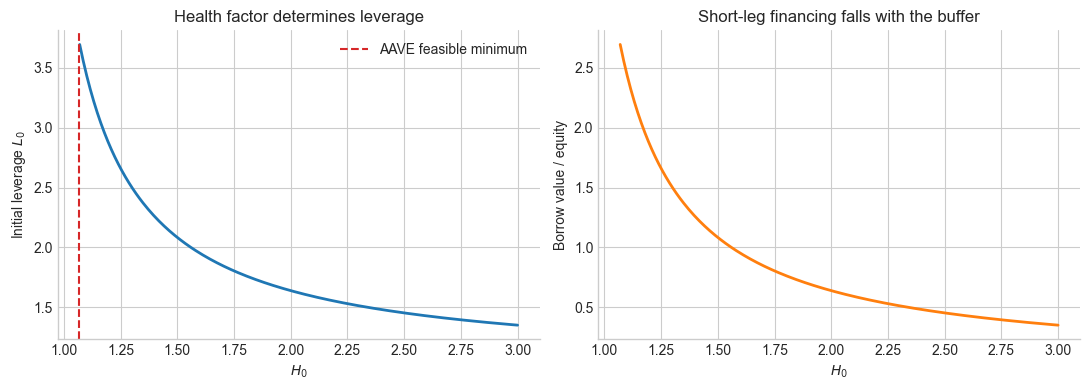

In [5]:
H0_grid = np.linspace(constraint["H0_min"] + 0.001, 3.0, 250)
leverage = H0_grid / (H0_grid - market.b)
borrow_to_equity = leverage - 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(H0_grid, leverage, lw=2)
axes[0].axvline(constraint["H0_min"], color="tab:red", ls="--", label="AAVE feasible minimum")
axes[0].set(xlabel="$H_0$", ylabel="Initial leverage $L_0$", title="Health factor determines leverage")
axes[0].legend()

axes[1].plot(H0_grid, borrow_to_equity, color="tab:orange", lw=2)
axes[1].set(xlabel="$H_0$", ylabel="Borrow value / equity", title="Short-leg financing falls with the buffer")
fig.tight_layout()
plt.show()

## 5. Takeaway

`UnitExposureLongShortStrategy` makes the paper's scalar reduction concrete: once `h0` is selected, holdings and leverage follow automatically. A larger initial health factor lowers leverage and the short-leg liability.